# Encounters QA Story Report

## What this is

> **Context & Scope**
> Scenario (public-safe)
>
> HarborPoint Health Plan receives weekly encounter batches from delegated vendors for multiple lines of business (e.g., Medicaid and Commercial). Before submitting these encounters to external reporting endpoints (state/federal programs), the Encounters team must catch blocking defects, prioritize remediation, and document a defensible audit trail.
>
> This evidence pack simulates that workflow end-to-end:
> - Row-level rejects (missing member/provider fields, invalid dates, eligibility outside coverage, duplicates, etc.)
> - Batch-level flags when operational thresholds are exceeded (duplicate rate >1%, eligibility mismatch >2%, volume shift >15%)
> - Ops decisions: Hold / Reprocess / Submit-with-monitoring
> - UAT traceability for upgrades and vendor feed changes
>
> Out of scope: This is not provider billing QA and not an EDI/837 parser; it's tabular pre-submit QA for payer encounter reporting.
Hiring-manager readable summary of a 10-week encounters QA story.

The report is intentionally narrative-first:
- W02 blockers
- W06 eligibility incident + `R902`
- W07 duplicate incident + `R901` + monitor noise
- W10 volume anomaly + `R903` only

All non-incident weeks are shown as `CLEAN` in the storyboard.

## Metric Definitions

See [Metric Definitions](metric_definitions.md) for canonical formulas (numerator/denominator), grain, and anomaly thresholds used in rejects, triage, and tracker outputs.

## Explain It Like I'm A Hiring Manager

- **Encounter:** A record of care delivered to a member, used to support plan reporting and payment operations.
- **Batch:** A weekly package of encounter records sent together for preparation, validation, and submission.
- **Reject:** A record-level failure found during validation that must be fixed before clean submission.
- **Batch anomaly flag:** A batch-level warning when rates or volume are abnormal, even if not every record is rejected.
- **Triage summary:** A weekly rollup that shows issue volume by severity so operations teams can decide what to do first.
- **Preparation:** Assembling the encounter batch and checks needed before it can be submitted.
- **Validation and submission:** Running quality checks first, then sending only approved data.
- **Remediation and reprocessing:** Correcting root causes, rerunning the batch, and confirming the fixes hold.
- **Resubmit:** Sending the corrected batch after reprocessing and final review.
- **User Acceptance Testing (UAT):** Documented tests and evidence that prove the workflow and controls work as intended.


## Code Legend (Batch Flags)

| Code | Name | Threshold | Action |
|---|---|---|---|
| R901 | Duplicate-rate anomaly | Duplicate rate > 1% of claims in a batch | Remediate and reprocess before submission |
| R902 | Eligibility-mismatch anomaly | Eligibility mismatch rate > 2% of claims in a batch | Remediate and reprocess before submission |
| R903 | Volume-shift anomaly | Weekly volume shift > 15% vs trailing median | Submit with monitoring controls and follow-up |

> **How to interpret this report**
> 1. Start with the storyboard to see what happened each week.
> 2. Read the decision column to see operational action (hold, remediate/reprocess, or monitor).
> 3. Use the at-a-glance table for severity totals and top driver codes.
> 4. Use the incident drilldowns and UAT evidence to confirm traceable proof.


In [1]:
from __future__ import annotations

import csv
import re
from datetime import date, datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

ROOT = Path.cwd().resolve().parents[0]
OUTPUTS = ROOT / "outputs"
DOCS = ROOT / "docs"
SCREENSHOTS = OUTPUTS / "screenshots"
SCREENSHOTS.mkdir(parents=True, exist_ok=True)

STORY_MAP_PATH = OUTPUTS / "story_map.csv"
TRIAGE_PATH = OUTPUTS / "triage_summary.csv"
TRIAGE_BY_CODE_PATH = OUTPUTS / "triage_by_code.csv"
REJECTS_PATH = OUTPUTS / "rejects.csv"
HEADER_PATH = ROOT / "data_raw" / "encounters_header.csv"

story_map = pd.read_csv(STORY_MAP_PATH, parse_dates=["week_start"])
triage = pd.read_csv(TRIAGE_PATH, parse_dates=["week_start"])
triage_by_code = pd.read_csv(TRIAGE_BY_CODE_PATH, parse_dates=["week_start"])
rejects = pd.read_csv(REJECTS_PATH, dtype=str, keep_default_na=False)
headers = pd.read_csv(HEADER_PATH, dtype=str, keep_default_na=False)

story_weeks = sorted(story_map["week_start"].dropna().dt.normalize().unique())
story_week_set = {pd.Timestamp(w).date().isoformat() for w in story_weeks}

INCIDENT_META = {
    "2026-03-02": {
        "label": "W02 BLOCKERS",
        "focus": "MEDICAID / VENDOR_A",
        "decision": "Hold submission (BLOCKER present)",
    },
    "2026-03-30": {
        "label": "W06 R902 ELIGIBILITY-MISMATCH ANOMALY (>2%)",
        "focus": "COMMERCIAL / VENDOR_B",
        "decision": "Remediate and reprocess before submit",
    },
    "2026-04-06": {
        "label": "W07 R901 DUPLICATE-RATE ANOMALY (>1%) + MONITORS",
        "focus": "COMMERCIAL / VENDOR_C",
        "decision": "Remediate duplicates; monitor financial/code-set noise",
    },
    "2026-04-27": {
        "label": "W10 R903 VOLUME-SHIFT ANOMALY (>15%)",
        "focus": "MEDICAID / VENDOR_A",
        "decision": "Submit with volume monitor controls",
    },
}

BATCH_DATE_RE = re.compile(r"^BATCH_(\d{8})")

def monday_of(d: date) -> date:
    return d - timedelta(days=d.weekday())

def parse_iso_date(raw: str) -> date | None:
    raw = (raw or "").strip()
    if not raw:
        return None
    try:
        return date.fromisoformat(raw)
    except ValueError:
        return None

def parse_batch_week(batch_id: str) -> date | None:
    m = BATCH_DATE_RE.match((batch_id or "").strip())
    if not m:
        return None
    try:
        d = datetime.strptime(m.group(1), "%Y%m%d").date()
    except ValueError:
        return None
    return monday_of(d)

def derive_week_start(row: pd.Series) -> pd.Timestamp | pd.NaT:
    # Contract lock: week_start derives from batch_id YYYYMMDD for all rows.
    batch_week = parse_batch_week(row.get("batch_id", ""))
    if batch_week is not None:
        return pd.Timestamp(batch_week)
    return pd.NaT

rejects["week_start"] = rejects.apply(derive_week_start, axis=1)
rejects = rejects[rejects["week_start"].notna()].copy()
rejects["week_start"] = rejects["week_start"].dt.normalize()

triage = triage.copy()
triage["week_start"] = triage["week_start"].dt.normalize()
triage["reject_count"] = pd.to_numeric(triage["reject_count"], errors="coerce").fillna(0).astype(int)
triage["affected_claims"] = pd.to_numeric(triage["affected_claims"], errors="coerce").fillna(0).astype(int)

# Keep report strictly in the 10-week story window.
triage_10w = triage[triage["week_start"].isin(story_weeks)].copy()
rejects_10w = rejects[rejects["week_start"].isin(story_weeks)].copy()

weekly_sev = (
    triage_10w.groupby(["week_start", "severity"], as_index=False)["reject_count"].sum()
    .pivot(index="week_start", columns="severity", values="reject_count")
    .fillna(0)
    .astype(int)
    .reset_index()
)
for col in ["BLOCKER", "HIGH", "MONITOR"]:
    if col not in weekly_sev.columns:
        weekly_sev[col] = 0
weekly_sev["total_rejects"] = weekly_sev[["BLOCKER", "HIGH", "MONITOR"]].sum(axis=1)

weekly = pd.DataFrame({"week_start": story_weeks}).merge(
    weekly_sev[["week_start", "BLOCKER", "HIGH", "MONITOR", "total_rejects"]],
    on="week_start",
    how="left",
)
weekly[["BLOCKER", "HIGH", "MONITOR", "total_rejects"]] = (
    weekly[["BLOCKER", "HIGH", "MONITOR", "total_rejects"]].fillna(0).astype(int)
)

def week_code_counts(week_ts: pd.Timestamp) -> dict[str, int]:
    wk = rejects_10w[rejects_10w["week_start"] == week_ts]
    vc = wk["reject_code"].value_counts()
    return {k: int(v) for k, v in vc.items()}

# Assertions to lock the intended story.
stable_weeks = [w for w in story_weeks if w.date().isoformat() not in INCIDENT_META]
stable_df = weekly[weekly["week_start"].isin(stable_weeks)]
assert (stable_df["total_rejects"] == 0).all(), "Stable weeks must be CLEAN (0 rejects)."

w06_counts = week_code_counts(pd.Timestamp("2026-03-30"))
assert w06_counts.get("ELIG_MISMATCH_GT_2PCT", 0) == 1, "W06 must include R902 anomaly row."

w07_counts = week_code_counts(pd.Timestamp("2026-04-06"))
assert w07_counts.get("DUP_RATE_GT_1PCT", 0) == 1, "W07 must include R901 anomaly row."
assert w07_counts.get("DUP_CLAIM_KEY", 0) > 0, "W07 must include duplicate claim keys."
assert w07_counts.get("PAID_GT_ALLOWED", 0) > 0 and w07_counts.get("ALLOWED_GT_CHARGE", 0) > 0, "W07 must include financial monitors."
assert w07_counts.get("NULL_PROC", 0) > 0 and w07_counts.get("NULL_DX", 0) > 0, "W07 must include code-set monitors."

w10_counts = week_code_counts(pd.Timestamp("2026-04-27"))
assert set(w10_counts.keys()) == {"VOLUME_SHIFT_GT_15PCT"}, "W10 must be R903 only."

# Derive weekly story labels from story_map (week grain), then normalize for report readability.
story_week_labels = (
    story_map.copy()
    .assign(week_start=lambda d: d["week_start"].dt.normalize())
    .groupby("week_start", as_index=False)["storyline_label"]
    .agg(lambda s: next((x for x in s if str(x).strip().upper() != "STABLE"), "STABLE"))
)

story_label_map = {
    "ONBOARDING_BLOCKERS": "W02 BLOCKERS",
    "ELIGIBILITY_INCIDENT": "W06 R902 ELIGIBILITY-MISMATCH ANOMALY (>2%)",
    "DUP_REPLAY_INCIDENT": "W07 R901 DUPLICATE-RATE ANOMALY (>1%) + MONITORS",
    "VOLUME_SPIKE": "W10 R903 VOLUME-SHIFT ANOMALY (>15%)",
    "STABLE": "CLEAN",
}

story_week_labels["storyline_label"] = story_week_labels["storyline_label"].map(story_label_map).fillna("CLEAN")

weekly = weekly.sort_values("week_start").reset_index(drop=True)
weekly = weekly.merge(story_week_labels, on="week_start", how="left")
weekly["storyline_label"] = weekly["storyline_label"].fillna("CLEAN")

def what_broke_text(row: pd.Series) -> str:
    key = row["week_start"].date().isoformat()
    if key == "2026-03-02":
        return "BLOCKER=70 from REQUIRED_FIELD (30), PROVIDER (30), DATES (10)."
    if key == "2026-03-30":
        return "HIGH=7 in MEMBER_ELIGIBILITY: R010=6 plus R902 anomaly=1."
    if key == "2026-04-06":
        return "HIGH=11 and MONITOR=120: DUP_CLAIM_KEY=10 + R901=1, FINANCIAL=80, CODE_SET=40."
    if key == "2026-04-27":
        return "MONITOR=1 from VOLUME_SHIFT_GT_15PCT (R903) only."
    return "CLEAN: no triage rejects in this week."

def decision_text(row: pd.Series) -> str:
    key = row["week_start"].date().isoformat()
    if key in INCIDENT_META:
        return INCIDENT_META[key]["decision"]
    return "Proceed; maintain routine monitor controls"

weekly["what_broke"] = weekly.apply(what_broke_text, axis=1)
weekly["decision"] = weekly.apply(decision_text, axis=1)

next_delta = []
next_label = []
for i, row in weekly.iterrows():
    if i == len(weekly) - 1:
        next_delta.append("End of window")
        next_label.append("End of window")
        continue

    nxt = weekly.iloc[i + 1]
    delta = int(nxt["total_rejects"] - row["total_rejects"])
    if delta > 0:
        delta_txt = f"+{delta} rejects"
    elif delta < 0:
        delta_txt = f"{delta} rejects"
    else:
        delta_txt = "0 rejects"

    nxt_label = str(nxt["storyline_label"]).strip() or "CLEAN"
    next_delta.append(delta_txt)
    next_label.append(nxt_label)

weekly["next_week_delta"] = next_delta
weekly["next_week_label"] = next_label

# Storyboard acceptance gates (exec readability split).
assert len(weekly) == 10, f"Storyboard must have 10 rows, found {len(weekly)}"
assert (weekly["storyline_label"].isin(["W02 BLOCKERS", "W06 R902 ELIGIBILITY-MISMATCH ANOMALY (>2%)", "W07 R901 DUPLICATE-RATE ANOMALY (>1%) + MONITORS", "W10 R903 VOLUME-SHIFT ANOMALY (>15%)", "CLEAN"]).all()), "Unexpected storyline_label value(s)"
assert (weekly["next_week_delta"].iloc[:-1].astype(str).str.strip() != "").all(), "next_week_delta blank in first 9 rows"
assert (weekly["next_week_label"].iloc[:-1].astype(str).str.strip() != "").all(), "next_week_label blank in first 9 rows"
assert str(weekly["next_week_delta"].iloc[-1]).strip() == "End of window", "Last row next_week_delta must be 'End of window'"
assert str(weekly["next_week_label"].iloc[-1]).strip() == "End of window", "Last row next_week_label must be 'End of window'"

storyboard_cols = [
    "week_start",
    "storyline_label",
    "what_broke",
    "decision",
    "next_week_delta",
    "next_week_label",
]
storyboard_df = weekly[storyboard_cols].copy()
storyboard_df["week_start"] = storyboard_df["week_start"].dt.strftime("%Y-%m-%d")

pd.set_option("display.max_colwidth", None)

assert not storyboard_df.astype(str).apply(
    lambda s: s.str.contains(r"\.\.\.", regex=True)
).any().any(), "Storyboard contains ellipsis ('...') which indicates truncation."

display(Markdown("## Storyboard (10-week timeline)"))
display(HTML("""
<style>
table.dataframe { width: 100%; table-layout: fixed; }
table.dataframe th, table.dataframe td {
    white-space: normal !important;
    overflow-wrap: anywhere;
    word-break: break-word;
    vertical-align: top;
}
</style>
"""))
display(HTML(storyboard_df.to_html(index=False)))

# Keep compatibility with downstream cells expecting `storyboard`.
storyboard = storyboard_df.copy()

## Storyboard (10-week timeline)

week_start,storyline_label,what_broke,decision,next_week_delta,next_week_label
2026-02-23,CLEAN,CLEAN: no triage rejects in this week.,Proceed; maintain routine monitor controls,+80 rejects,W02 BLOCKERS
2026-03-02,W02 BLOCKERS,"BLOCKER=70 from REQUIRED_FIELD (30), PROVIDER (30), DATES (10).",Hold submission (BLOCKER present),-80 rejects,CLEAN
2026-03-09,CLEAN,CLEAN: no triage rejects in this week.,Proceed; maintain routine monitor controls,0 rejects,CLEAN
2026-03-16,CLEAN,CLEAN: no triage rejects in this week.,Proceed; maintain routine monitor controls,0 rejects,CLEAN
2026-03-23,CLEAN,CLEAN: no triage rejects in this week.,Proceed; maintain routine monitor controls,+7 rejects,W06 R902 ELIGIBILITY-MISMATCH ANOMALY (>2%)
2026-03-30,W06 R902 ELIGIBILITY-MISMATCH ANOMALY (>2%),HIGH=7 in MEMBER_ELIGIBILITY: R010=6 plus R902 anomaly=1.,Remediate and reprocess before submit,+124 rejects,W07 R901 DUPLICATE-RATE ANOMALY (>1%) + MONITORS
2026-04-06,W07 R901 DUPLICATE-RATE ANOMALY (>1%) + MONITORS,"HIGH=11 and MONITOR=120: DUP_CLAIM_KEY=10 + R901=1, FINANCIAL=80, CODE_SET=40.",Remediate duplicates; monitor financial/code-set noise,-131 rejects,CLEAN
2026-04-13,CLEAN,CLEAN: no triage rejects in this week.,Proceed; maintain routine monitor controls,0 rejects,CLEAN
2026-04-20,CLEAN,CLEAN: no triage rejects in this week.,Proceed; maintain routine monitor controls,+1 rejects,W10 R903 VOLUME-SHIFT ANOMALY (>15%)
2026-04-27,W10 R903 VOLUME-SHIFT ANOMALY (>15%),MONITOR=1 from VOLUME_SHIFT_GT_15PCT (R903) only.,Submit with volume monitor controls,End of window,End of window


In [2]:
sev = triage_10w.groupby("severity", as_index=False)["reject_count"].sum()
sev_map = {r["severity"]: int(r["reject_count"]) for _, r in sev.iterrows()}

total_rejects = int(triage_10w["reject_count"].sum())

anomaly_counts = (
    rejects_10w[
        rejects_10w["reject_code"].isin(
            ["DUP_RATE_GT_1PCT", "ELIG_MISMATCH_GT_2PCT", "VOLUME_SHIFT_GT_15PCT"]
        )
    ]["reject_code"]
    .value_counts()
    .to_dict()
)

findings = [
    f"- Total 10-week triage reject volume: **{total_rejects:,}** (**BLOCKER={sev_map.get('BLOCKER', 0):,}**, **HIGH={sev_map.get('HIGH', 0):,}**, **MONITOR={sev_map.get('MONITOR', 0):,}**).",
    "- Stable weeks are **CLEAN** (0 rejects): 2026-02-23, 2026-03-09, 2026-03-16, 2026-03-23, 2026-04-13, 2026-04-20.",
    "- Four incidents are explicit in trend and storyboard: **W02 blockers**, **W06 eligibility + R902**, **W07 duplicates + R901 + monitors**, **W10 volume + R903 only**.",
    f"- Batch anomaly signals detected in-window: **R901={anomaly_counts.get('DUP_RATE_GT_1PCT', 0)}**, **R902={anomaly_counts.get('ELIG_MISMATCH_GT_2PCT', 0)}**, **R903={anomaly_counts.get('VOLUME_SHIFT_GT_15PCT', 0)}**.",
]

display(Markdown("## Key Findings"))
display(Markdown(chr(10).join(findings)))


## Key Findings

- Total 10-week triage reject volume: **219** (**BLOCKER=80**, **HIGH=18**, **MONITOR=121**).
- Stable weeks are **CLEAN** (0 rejects): 2026-02-23, 2026-03-09, 2026-03-16, 2026-03-23, 2026-04-13, 2026-04-20.
- Four incidents are explicit in trend and storyboard: **W02 blockers**, **W06 eligibility + R902**, **W07 duplicates + R901 + monitors**, **W10 volume + R903 only**.
- Batch anomaly signals detected in-window: **R901=1**, **R902=1**, **R903=1**.

In [3]:
# Story at a glance: one row per week with decision contract and top drivers
plot_codes = rejects_10w[["week_start", "reject_code"]].copy()
plot_codes["reject_code"] = plot_codes["reject_code"].fillna("").astype(str)
plot_codes["reject_code"] = plot_codes["reject_code"].where(
    ~plot_codes["reject_code"].str.strip().isin(["", "NULL", "null"]),
    "(BLANK_CODE)",
)

code_counts = (
    plot_codes.groupby(["week_start", "reject_code"], as_index=False)
    .size()
    .rename(columns={"size": "rows"})
)
code_counts = code_counts.sort_values(["week_start", "rows", "reject_code"], ascending=[True, False, True])

top3_by_week = (
    code_counts.groupby("week_start", as_index=False)
    .head(3)
    .groupby("week_start")["reject_code"]
    .apply(lambda s: ", ".join(s.tolist()))
    .to_dict()
)

glance = weekly[["week_start", "storyline_label", "BLOCKER", "HIGH", "MONITOR"]].copy()
glance = glance.sort_values("week_start").reset_index(drop=True)

def decision_contract(row: pd.Series) -> str:
    if int(row["BLOCKER"]) > 0:
        return "Hold"
    if int(row["HIGH"]) > 0:
        return "Remediate"
    return "Monitor"

glance["decision"] = glance.apply(decision_contract, axis=1)
glance["top_driver_codes"] = glance["week_start"].map(top3_by_week).fillna("(none)")

glance = glance.rename(
    columns={
        "storyline_label": "story_label",
        "BLOCKER": "blockers",
        "HIGH": "high",
        "MONITOR": "monitor",
    }
)
glance["week_start"] = glance["week_start"].dt.strftime("%Y-%m-%d")

glance = glance[["week_start", "story_label", "decision", "blockers", "high", "monitor", "top_driver_codes"]]

# Acceptance guardrails
assert len(glance) == 10, f"Expected 10 weekly rows, found {len(glance)}"
assert {"W02 BLOCKERS", "W06 R902 ELIGIBILITY-MISMATCH ANOMALY (>2%)", "W07 R901 DUPLICATE-RATE ANOMALY (>1%) + MONITORS", "W10 R903 VOLUME-SHIFT ANOMALY (>15%)"}.issubset(set(glance["story_label"]))
assert (
    ((glance["blockers"] > 0) & (glance["decision"] == "Hold"))
    | ((glance["blockers"] == 0) & (glance["high"] > 0) & (glance["decision"] == "Remediate"))
    | ((glance["blockers"] == 0) & (glance["high"] == 0) & (glance["decision"] == "Monitor"))
).all(), "Decision contract check failed"

display(Markdown("## Story at a glance"))
display(glance)


## Story at a glance

,week_start,story_label,decision,blockers,high,monitor,top_driver_codes
0,2026-02-23,CLEAN,Monitor,0,0,0,(none)
1,2026-03-02,W02 BLOCKERS,Hold,80,0,0,"FUTURE_SERVICE_DATE, NPI_BAD_LENGTH, NPI_NOT_FOUND"
2,2026-03-09,CLEAN,Monitor,0,0,0,(none)
3,2026-03-16,CLEAN,Monitor,0,0,0,(none)
4,2026-03-23,CLEAN,Monitor,0,0,0,(none)
5,2026-03-30,W06 R902 ELIGIBILITY-MISMATCH ANOMALY (>2%),Remediate,0,7,0,"SERVICE_OUTSIDE_COVERAGE, ELIG_MISMATCH_GT_2PCT"
6,2026-04-06,W07 R901 DUPLICATE-RATE ANOMALY (>1%) + MONITORS,Remediate,0,11,120,"ALLOWED_GT_CHARGE, PAID_GT_ALLOWED, NULL_DX"
7,2026-04-13,CLEAN,Monitor,0,0,0,(none)
8,2026-04-20,CLEAN,Monitor,0,0,0,(none)
9,2026-04-27,W10 R903 VOLUME-SHIFT ANOMALY (>15%),Monitor,0,0,1,VOLUME_SHIFT_GT_15PCT



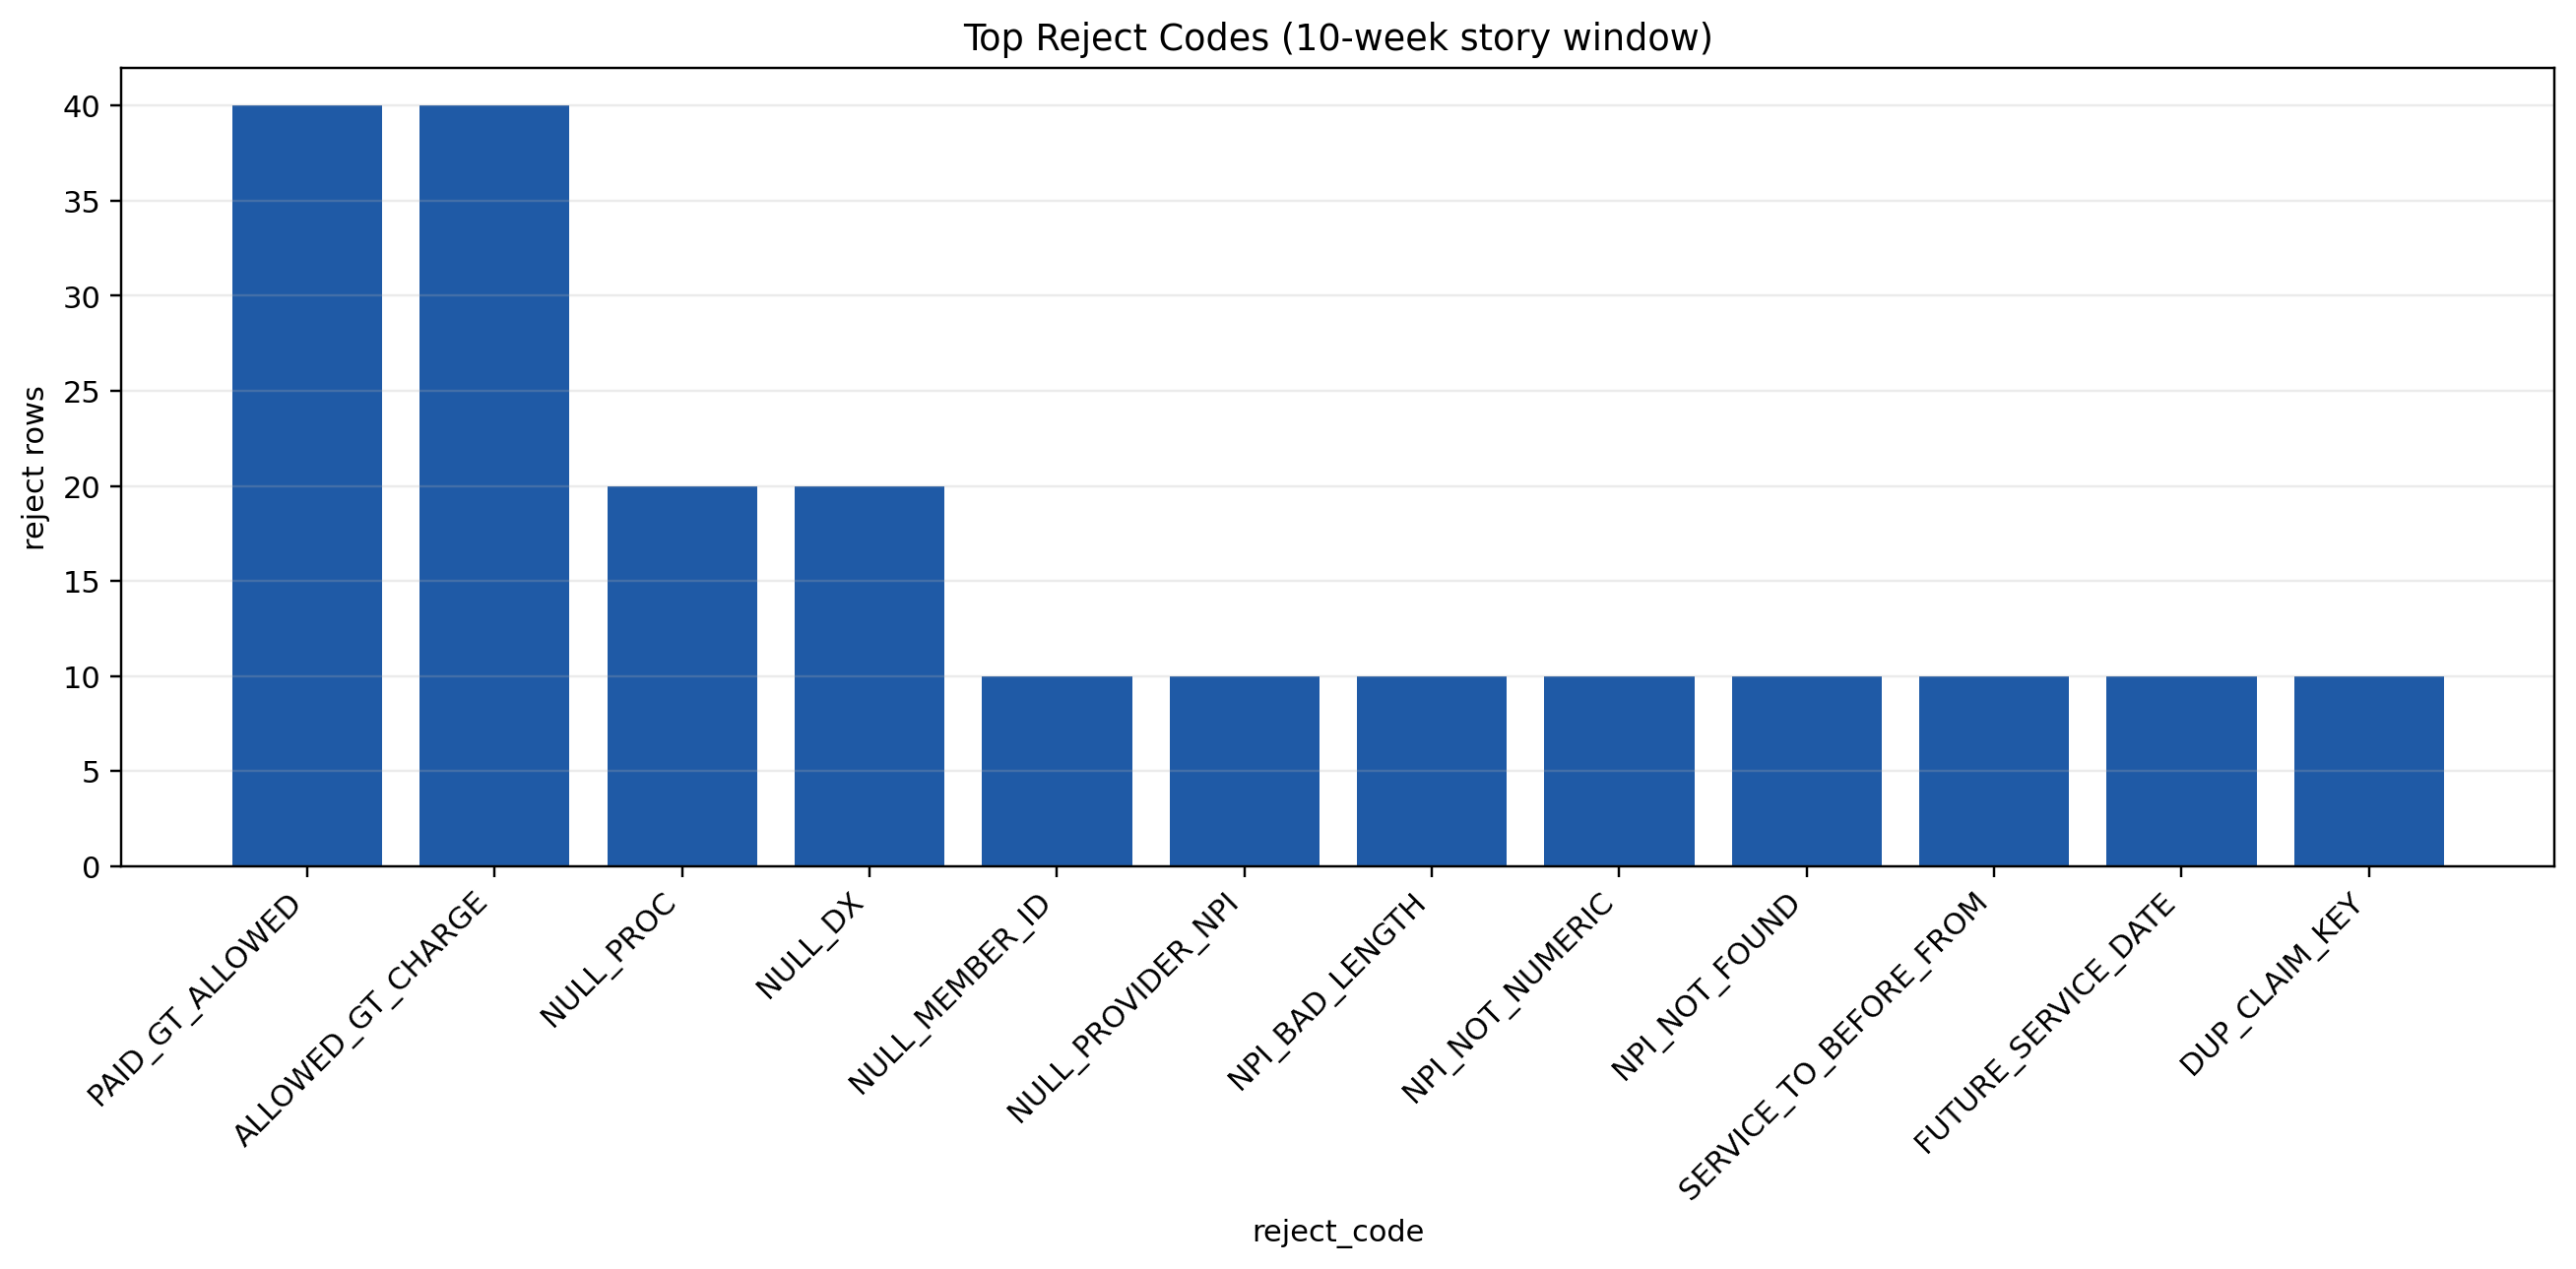

In [4]:
# Visual 1: Top Reject Codes (readable in PDF, explicit x labels)
plot_codes = rejects_10w["reject_code"].copy()

# Normalize blanks/NULL literals for plotting only.
blank_mask = plot_codes.fillna("").astype(str).str.strip().eq("")
null_literal_mask = plot_codes.fillna("").astype(str).str.strip().str.upper().eq("NULL")
replace_mask = blank_mask | null_literal_mask

blank_count = int(replace_mask.sum())
if blank_count > 0:
    print(f"WARNING: Found {blank_count} blank/NULL reject_code values; replacing with '(BLANK_CODE)' for plot labels.")

plot_codes = plot_codes.where(~replace_mask, "(BLANK_CODE)")

top = (
    plot_codes.value_counts(dropna=False)
    .rename_axis("reject_code")
    .reset_index(name="rows")
    .head(12)
)

# Guarantee no blank labels post-cleaning.
assert (top["reject_code"].astype(str).str.strip() != "").all(), "Top reject_code labels contain blanks after cleaning."

codes = top["reject_code"].tolist()
counts = top["rows"].tolist()
x = np.arange(len(codes))

fig, ax = plt.subplots(figsize=(12, 5.8))
bars = ax.bar(x, counts, color="#1f5aa6")
ax.set_title("Top Reject Codes (10-week story window)")
ax.set_ylabel("reject rows")
ax.set_xlabel("reject_code")
ax.set_xticks(x)
ax.set_xticklabels(codes, rotation=45, ha="right")
ax.grid(axis="y", alpha=0.25)

# Extra bottom margin + tight bounding box to avoid clipped labels in PDF export.
fig.tight_layout()
fig.subplots_adjust(bottom=0.30)
visual1_path = SCREENSHOTS / "top_rejects.png"
fig.savefig(visual1_path, dpi=220, bbox_inches="tight")
import base64
from IPython.display import HTML
visual1_b64 = base64.b64encode(visual1_path.read_bytes()).decode("ascii")
display(HTML(f'<img alt="Top reject codes chart" src="data:image/png;base64,{visual1_b64}" style="max-width:100%;height:auto;"/>'))
plt.close(fig)


In [5]:
# Visual QA gate 1: Top Reject Codes (fail-fast)
assert visual1_path.exists(), f"Visual 1 missing: {visual1_path}"
visual1_size = int(visual1_path.stat().st_size)
assert visual1_size > 20 * 1024, f"Visual 1 appears broken/small ({visual1_size} bytes <= 20KB): {visual1_path}"
assert len(codes) == len(bars), f"Visual 1 label/bar mismatch: labels={len(codes)} bars={len(bars)}"
assert all(str(lbl).strip() != "" for lbl in codes), "Visual 1 contains empty x-axis label(s) after cleaning"
print(f"Visual QA PASS (Visual 1): bars={len(bars)}, labels={len(codes)}, size={visual1_size} bytes")


Visual QA PASS (Visual 1): bars=12, labels=12, size=142645 bytes



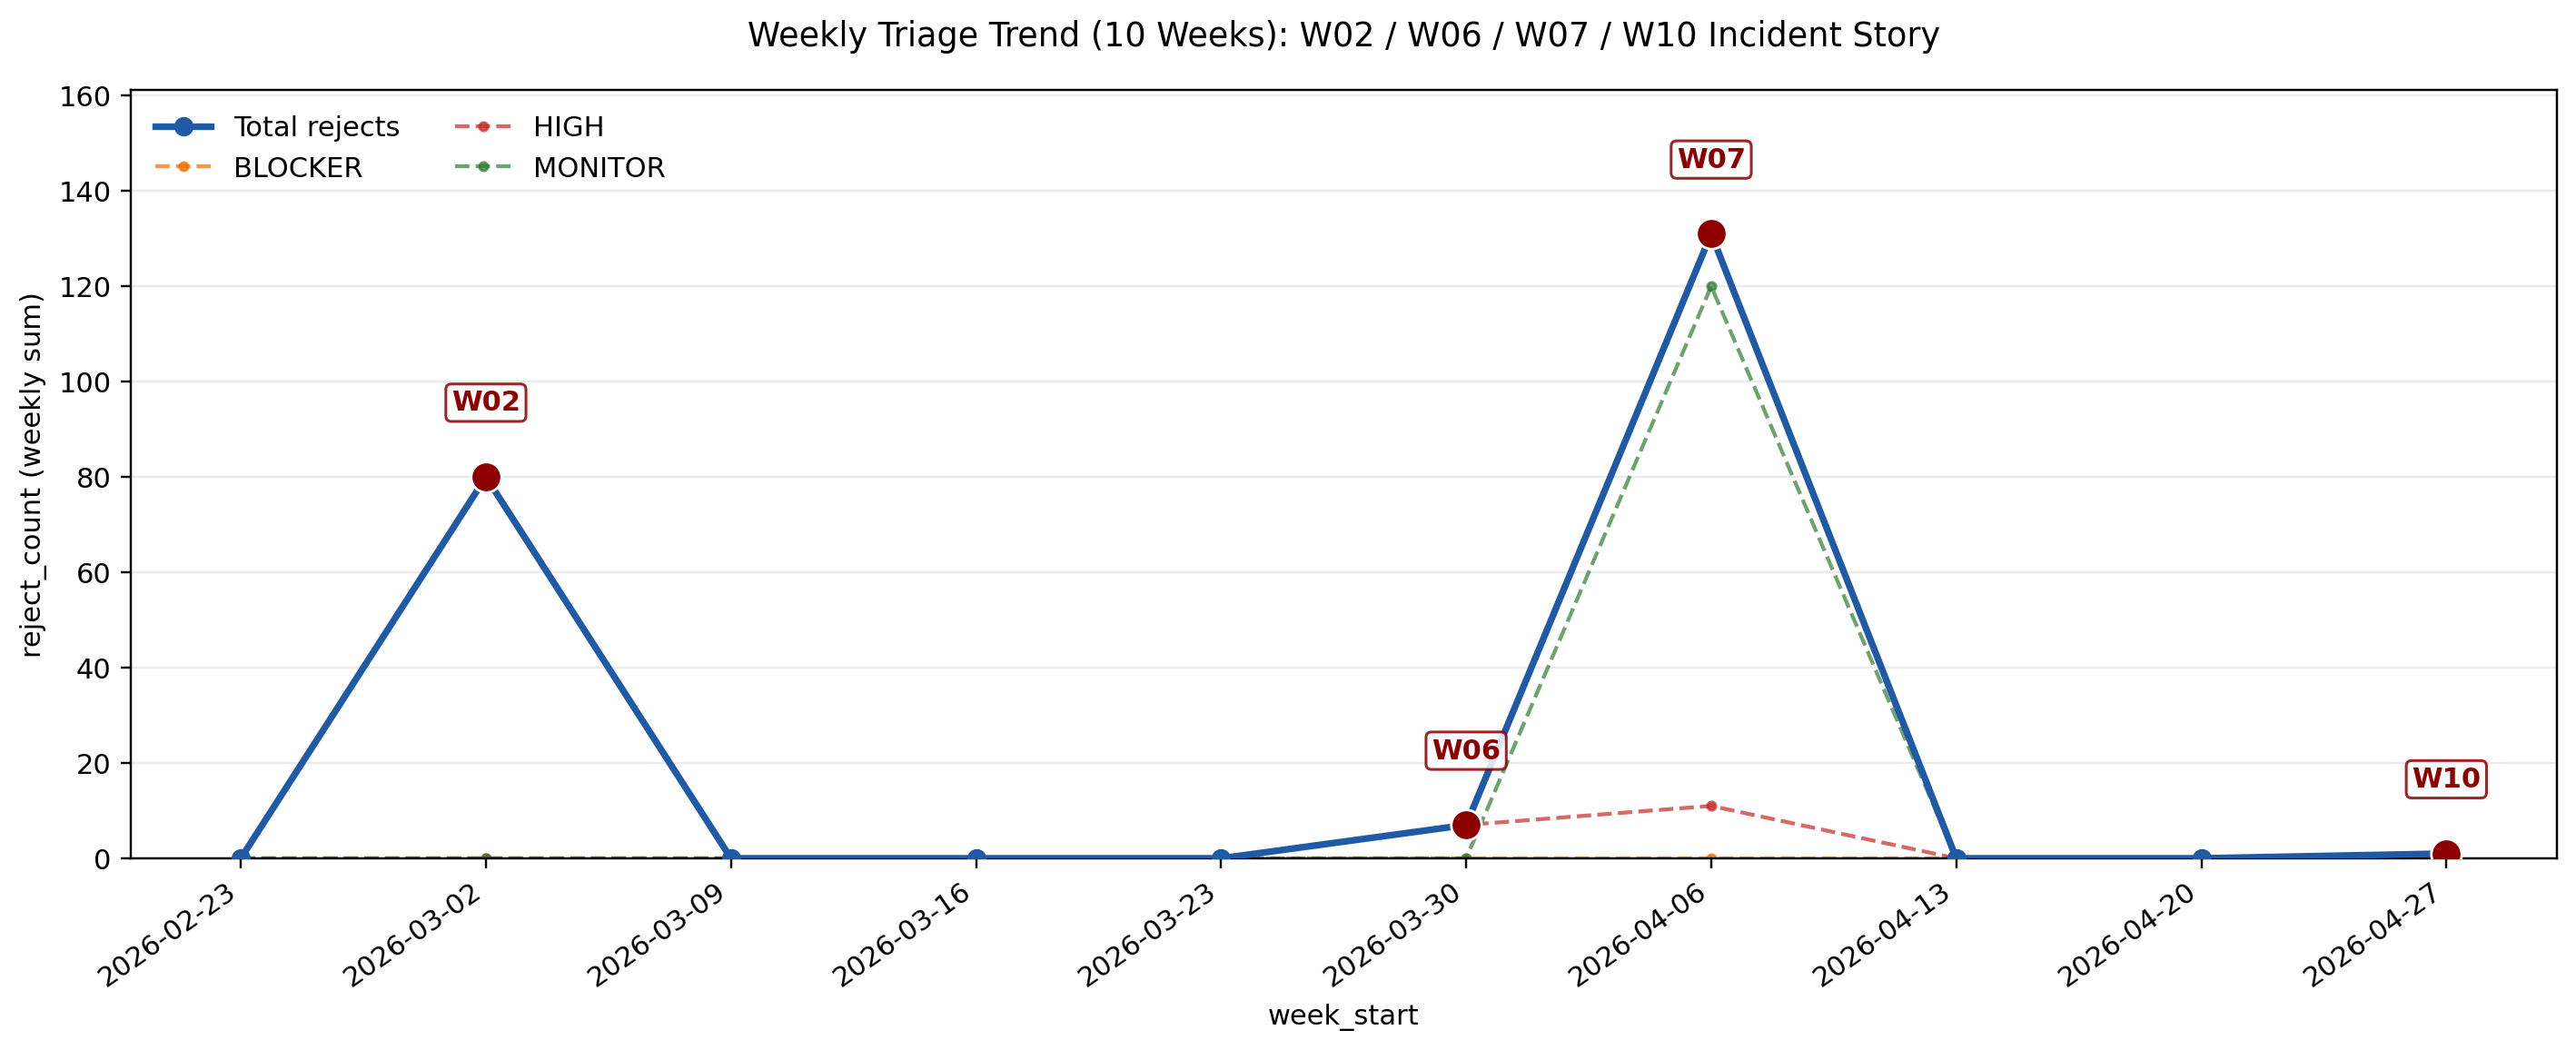

In [6]:
# Visual 2: Weekly triage trend with explicit 10-week axis and incident callouts
trend = (
    weekly[["week_start", "BLOCKER", "HIGH", "MONITOR", "total_rejects"]]
    .copy()
    .sort_values("week_start")
    .reset_index(drop=True)
)

# Join story_map at week grain to identify incident weeks from dataset story labels.
story_week_labels = (
    story_map.copy()
    .assign(week_start=lambda d: d["week_start"].dt.normalize())
    .groupby("week_start", as_index=False)["storyline_label"]
    .agg(lambda s: next((x for x in s if str(x).strip().upper() != "STABLE"), "STABLE"))
)

trend = trend.merge(story_week_labels, on="week_start", how="left")
trend["storyline_label"] = trend["storyline_label"].fillna("STABLE")

incident_label_map = {
    "ONBOARDING_BLOCKERS": "W02",
    "ELIGIBILITY_INCIDENT": "W06",
    "DUP_REPLAY_INCIDENT": "W07",
    "VOLUME_SPIKE": "W10",
}
trend["incident_tag"] = trend["storyline_label"].map(incident_label_map)

# Guardrail: ensure all 4 incident tags are present from story_map join.
expected_tags = {"W02", "W06", "W07", "W10"}
found_tags = set(trend["incident_tag"].dropna().tolist())
assert expected_tags.issubset(found_tags), f"Missing incident tags on trend plot: {sorted(expected_tags - found_tags)}"

x = np.arange(len(trend))
week_labels = trend["week_start"].dt.strftime("%Y-%m-%d").tolist()

total = trend["total_rejects"].to_numpy()
blocker = trend["BLOCKER"].to_numpy()
high = trend["HIGH"].to_numpy()
monitor = trend["MONITOR"].to_numpy()

fig, ax = plt.subplots(figsize=(13, 6.2))

# Main story line: weekly total rejects.
ax.plot(x, total, color="#1f5aa6", linewidth=2.4, marker="o", label="Total rejects", zorder=3)

# Optional severity overlays (lightweight, readable).
ax.plot(x, blocker, color="#ef6c00", linewidth=1.4, linestyle="--", alpha=0.70, marker=".", label="BLOCKER")
ax.plot(x, high, color="#c62828", linewidth=1.4, linestyle="--", alpha=0.70, marker=".", label="HIGH")
ax.plot(x, monitor, color="#2e7d32", linewidth=1.4, linestyle="--", alpha=0.70, marker=".", label="MONITOR")

# Incident markers + labels from story_map join.
incident_color = "#8e0000"
for i, row in trend.iterrows():
    tag = row["incident_tag"]
    if pd.isna(tag):
        continue

    y = int(row["total_rejects"])
    ax.scatter(i, y, s=120, color=incident_color, edgecolor="white", linewidth=0.9, zorder=5)
    ax.annotate(
        str(tag),
        xy=(i, y),
        xytext=(0, 22),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=incident_color,
        bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "edgecolor": incident_color, "alpha": 0.85},
    )

ax.set_title("Weekly Triage Trend (10 Weeks): W02 / W06 / W07 / W10 Incident Story", pad=16)
ax.set_ylabel("reject_count (weekly sum)")
ax.set_xlabel("week_start")
ax.set_xticks(x)
ax.set_xticklabels(week_labels, rotation=35, ha="right")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper left", ncol=2, frameon=False)
ax.set_ylim(bottom=0, top=max(total) * 1.23 if len(total) else 1)

# Layout/export tuned for PDF readability (no clipped labels, no title overlap).
fig.tight_layout()
fig.subplots_adjust(bottom=0.24, top=0.86)
visual2_path = SCREENSHOTS / "triage_trend.png"
fig.savefig(visual2_path, dpi=220, bbox_inches="tight")
import base64
from IPython.display import HTML
visual2_b64 = base64.b64encode(visual2_path.read_bytes()).decode("ascii")
display(HTML(f'<img alt="Weekly triage trend chart" src="data:image/png;base64,{visual2_b64}" style="max-width:100%;height:auto;"/>'))
plt.close(fig)


In [7]:
# Visual QA gate 2: Weekly Triage Trend (fail-fast)
assert visual2_path.exists(), f"Visual 2 missing: {visual2_path}"
visual2_size = int(visual2_path.stat().st_size)
assert visual2_size > 20 * 1024, f"Visual 2 appears broken/small ({visual2_size} bytes <= 20KB): {visual2_path}"
print(f"Visual QA PASS (Visual 2): size={visual2_size} bytes")


Visual QA PASS (Visual 2): size=180649 bytes


In [8]:
def incident_tables(week: str, lob: str, vendor: str, title: str):
    week_ts = pd.Timestamp(week)
    tri = triage_10w[(triage_10w["week_start"] == week_ts) & (triage_10w["lob"] == lob) & (triage_10w["vendor"] == vendor)].copy()
    rej = rejects_10w[(rejects_10w["week_start"] == week_ts) & (rejects_10w["lob"] == lob) & (rejects_10w["vendor"] == vendor)].copy()

    tri_view = tri[["reject_category", "severity", "reject_count", "affected_claims"]].sort_values(
        ["severity", "reject_category"]
    )
    rej_view = (
        rej["reject_code"].value_counts().rename_axis("reject_code").reset_index(name="rows")
    )

    display(Markdown(f"### {title}"))
    display(Markdown("Triage rollup"))
    display(tri_view)
    display(Markdown("Reject-code detail"))
    display(rej_view)

incident_tables("2026-03-02", "MEDICAID", "VENDOR_A", "W02 incident: blockers")
incident_tables("2026-03-30", "COMMERCIAL", "VENDOR_B", "W06 incident: eligibility + R902")
incident_tables("2026-04-06", "COMMERCIAL", "VENDOR_C", "W07 incident: duplicates + R901 + monitors")
incident_tables("2026-04-27", "MEDICAID", "VENDOR_A", "W10 incident: volume + R903 only")

### W02 incident: blockers

Triage rollup

,reject_category,severity,reject_count,affected_claims
0,DATES,BLOCKER,20,20
1,PROVIDER,BLOCKER,30,30
2,REQUIRED_FIELD,BLOCKER,30,25


Reject-code detail

,reject_code,rows
0,NULL_MEMBER_ID,10
1,NULL_PROVIDER_NPI,10
2,NPI_BAD_LENGTH,10
3,NPI_NOT_NUMERIC,10
4,NPI_NOT_FOUND,10
5,SERVICE_TO_BEFORE_FROM,10
6,FUTURE_SERVICE_DATE,10
7,NULL_SERVICE_FROM,5
8,NULL_CLAIM_ID,5


...

### W10 incident: volume + R903 only

Triage rollup

,reject_category,severity,reject_count,affected_claims
7,VOLUME_ANOMALY,MONITOR,1,1


Reject-code detail

,reject_code,rows
0,VOLUME_SHIFT_GT_15PCT,1


In [9]:
# RCA helper: Top Drivers by Week from triage_by_code.csv
driver_weekly = (
    triage_by_code[triage_by_code["week_start"].isin(story_weeks)]
    .groupby(["week_start", "reject_code"], as_index=False)["reject_count"]
    .sum()
    .sort_values(["week_start", "reject_count", "reject_code"], ascending=[True, False, True])
)

top_drivers = (
    driver_weekly.groupby("week_start", as_index=False)
    .head(3)
    .copy()
)
top_drivers["week_start"] = top_drivers["week_start"].dt.strftime("%Y-%m-%d")

display(Markdown("## Top Drivers by Week (triage_by_code)"))
display(top_drivers[["week_start", "reject_code", "reject_count"]].reset_index(drop=True))


## Top Drivers by Week (triage_by_code)

,week_start,reject_code,reject_count
0,2026-03-02,FUTURE_SERVICE_DATE,10
1,2026-03-02,NPI_BAD_LENGTH,10
2,2026-03-02,NPI_NOT_FOUND,10
3,2026-03-30,SERVICE_OUTSIDE_COVERAGE,6
4,2026-03-30,ELIG_MISMATCH_GT_2PCT,1
5,2026-04-06,ALLOWED_GT_CHARGE,40
6,2026-04-06,PAID_GT_ALLOWED,40
7,2026-04-06,NULL_DX,20
8,2026-04-27,VOLUME_SHIFT_GT_15PCT,1


In [10]:
lines = []
lines.append("# Encounters QA Storyboard")
lines.append("")
lines.append("## Storyboard (10-week timeline)")
lines.append("")
lines.append("| week_start | storyline_label | what broke | decision | next_week_delta | next_week_label |")
lines.append("| --- | --- | --- | --- | --- | --- |")

for _, row in storyboard.iterrows():
    lines.append(
        f"| {row['week_start']} | {row['storyline_label']} | {row['what_broke']} | {row['decision']} | {row['next_week_delta']} | {row['next_week_label']} |"
    )

lines.append("")
lines.append("## Key Findings")
lines.append("")
lines.append(f"- Total triage reject volume in story window is **{int(triage_10w['reject_count'].sum()):,}**.")
lines.append("- Stable weeks are **CLEAN** with no reject surprises.")
lines.append("- Incident pattern is explicit: W02 blockers, W06 eligibility + R902, W07 duplicates + R901 + monitors, W10 volume + R903 only.")
lines.append("- Visual evidence exported to `outputs/screenshots/top_rejects.png` and `outputs/screenshots/triage_trend.png`.")

content = chr(10).join(lines) + chr(10)
out_path = DOCS / "STORYBOARD.md"
out_path.write_text(content, encoding="utf-8")
print("Wrote docs/STORYBOARD.md")


Wrote docs/STORYBOARD.md
